# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [53]:
!pip install mlflow==2.19.0

In [54]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

try:
    import mlflow
    mlflow_available = True
    print("MLflow berhasil diimport (versi:", mlflow.__version__, ")")
except ImportError:
    mlflow_available = False
    print("MLflow tidak tersedia. Eksperimen akan berjalan tanpa logging MLflow.")

print("Semua library berhasil diimport.")

MLflow berhasil diimport (versi: 2.19.0 )
Semua library berhasil diimport.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [55]:
dataset_name = "Midterm_53_group"
df = pd.read_csv(f'{dataset_name}.csv')
print(f"Dataset {dataset_name} dimuat: {df.shape[0]} baris, {df.shape[1]} kolom")

Dataset Midterm_53_group dimuat: 99 baris, 7 kolom


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Time         99 non-null     float64
 1   Source       99 non-null     object 
 2   No.          99 non-null     int64  
 3   Destination  99 non-null     object 
 4   Protocol     99 non-null     object 
 5   Length       99 non-null     int64  
 6   Info         99 non-null     object 
dtypes: float64(1), int64(2), object(4)
memory usage: 5.5+ KB

=== Statistik Deskriptif ===

=== Missing Values ===
Tidak ada missing value.


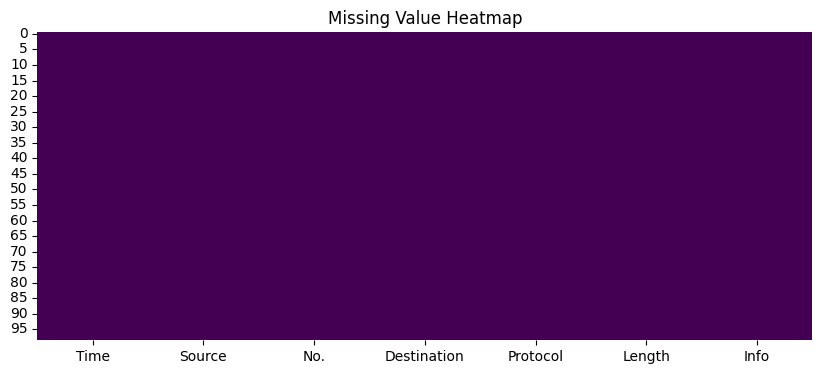

In [56]:
print("=== Informasi Dataset ===")
df.info()

print("\n=== Statistik Deskriptif ===")
df.describe()

# Missing values
missing = df.isnull().sum()
print("\n=== Missing Values ===")
print(missing[missing > 0] if any(missing > 0) else "Tidak ada missing value.")

# Visualisasi missing
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Heatmap")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [57]:
df_clean = df.copy()
initial_rows = df_clean.shape[0]

# 1. Handle missing values
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_clean[col].isnull().any():
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

categorical_cols = df_clean.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df_clean[col].isnull().any():
        mode_val = df_clean[col].mode()[0] if not df_clean[col].mode().empty else "Unknown"
        df_clean[col].fillna(mode_val, inplace=True)

print(f"Missing values ditangani. Tersisa: {df_clean.isnull().sum().sum()} missing")

# 2. Hapus duplikat
df_clean = df_clean.drop_duplicates()
duplicates_removed = initial_rows - df_clean.shape[0]
print(f"Duplikat dihapus: {duplicates_removed} baris")

# 3. Standarisasi numerik (kecuali kolom target jika diketahui)
target_col = df_clean.columns[-1]
feature_cols = [c for c in numeric_cols if c != target_col]

if feature_cols:
    scaler = StandardScaler()
    df_clean[feature_cols] = scaler.fit_transform(df_clean[feature_cols])
    print(f"Standarisasi pada {len(feature_cols)} fitur numerik.")

# 4. Deteksi outlier (IQR) dan hapus
Q1 = df_clean[feature_cols].quantile(0.25)
Q3 = df_clean[feature_cols].quantile(0.75)
IQR = Q3 - Q1
outlier_cond = ((df_clean[feature_cols] < (Q1 - 1.5 * IQR)) | (df_clean[feature_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
outliers_removed = outlier_cond.sum()
df_clean = df_clean[~outlier_cond]
print(f"Outlier dihapus: {outliers_removed} baris")

# 5. Encoding kategorikal
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le
    print(f"Encoding selesai untuk kolom: {col}")

print(f"\nData akhir: {df_clean.shape[0]} baris, {df_clean.shape[1]} kolom")
df_clean.head()

Missing values ditangani. Tersisa: 0 missing
Duplikat dihapus: 0 baris
Standarisasi pada 3 fitur numerik.
Outlier dihapus: 29 baris
Encoding selesai untuk kolom: Source
Encoding selesai untuk kolom: Destination
Encoding selesai untuk kolom: Protocol
Encoding selesai untuk kolom: Info

Data akhir: 70 baris, 7 kolom


,Time,Source,No.,Destination,Protocol,Length,Info
8,-1.668868,1,-1.434701,1,0,-0.33889,5
9,-1.577310,1,-1.399708,1,0,-0.33889,5
10,-1.485744,1,-1.364716,1,0,-0.33889,5
11,-0.943657,1,-1.329723,1,0,-0.33889,5
12,-0.852094,1,-1.294730,1,0,-0.33889,5


In [58]:
output_dir = "preprocessing"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "Midterm_53_group_processed.csv")
df_clean.to_csv(output_path, index=False)
print(f"Data preprocessing selesai. File disimpan di: {output_path}")

Data preprocessing selesai. File disimpan di: preprocessing/Midterm_53_group_processed.csv


In [59]:
if mlflow_available:
    try:
        with mlflow.start_run(run_name="Eksperimen_Preprocessing_Reza"):
            mlflow.log_param("dataset_name", dataset_name)
            mlflow.log_param("initial_rows", initial_rows)
            mlflow.log_param("final_rows", df_clean.shape[0])
            mlflow.log_metric("duplicates_removed", duplicates_removed)
            mlflow.log_metric("outliers_removed", outliers_removed)
            mlflow.log_artifact(output_path)
            print("Eksperimen berhasil di-log ke MLflow.")
    except Exception as e:
        print(f"Gagal logging ke MLflow: {e}")
else:
    print("MLflow tidak tersedia, lewati logging.")

Eksperimen berhasil di-log ke MLflow.
